# Week 03: Dimensionality Reduction and Similarities

## Text as Data

Professor: Elliott Ash, NYU

TA: Eduardo Zago, NYU

More accurate objective of the course: learning how to use text as data for research objectives, while also trying to understand how to build an LLM from scratch.

What have we done so far:

1.   Introduction to tools to manage text in Python
2.   Preprocessing of text
3.   Tokenization of text (encoder-decoder algorithms)

Now, how do we represent this tokens mathematically? And what can we do with this representations?

In [2]:
# set random seed
import numpy as np
import warnings
warnings.simplefilter("ignore", DeprecationWarning)
import warnings; warnings.simplefilter('ignore')
%matplotlib inline
import pandas as pd
import re
import matplotlib.pyplot as plt
from string import punctuation

!pip install gensim

import spacy
nlp = spacy.load('en_core_web_sm')

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import sent_tokenize

!pip install pyLDAvis

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
from google.colab import files
uploaded = files.upload()

In [3]:
df = pd.read_pickle('sc_cases_cleaned.pkl',
                    compression = 'gzip')

# Basic preprocessing for the dataset
translator = str.maketrans(' ', ' ', punctuation)
from nltk.tokenize import word_tokenize

def preprocess(doc):
  doc = doc.replace('\r', ' ').replace('\n', ' ')
  doc = re.sub(r"(\d)([A-Za-z])", r"\1 \2", doc) # separate numbers from strings
  doc = re.sub(r"([A-Za-z])(\d)", r"\1 \2", doc) # separate strings from numbers
  d = doc.translate(translator).lower() # remove punctuation
  words = word_tokenize(d)
  words = [w for w in words if w not in stoplist] # remove stopwords
  words = [w if not w.isdigit() else '#' for w in words] # normalize numbers
  output = ' '.join(words) # Let's not tokenize now
  return output

Last lab we introduced how one would represent mathemathically a corpus: term document matrix X, where

1. rows = documents
2. columns = tokens (words or n-grams)
3. values = counts

In [4]:
preprocessed_opinion = list(map(preprocess, df['opinion_text'])) # Note list()

# Generate a date - judge index
df['index'] = df['authorship'] + df['date_standard'].astype(str)

from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(min_df=0.01,
                      max_df=.9,
                      max_features=1000)

X = vec.fit_transform(preprocessed_opinion)

vocab_opinions = vec.get_feature_names_out()
X_lab = pd.DataFrame(X.toarray(), columns=vocab_opinions, index=df['index']) # only for didactic purposes, keep only the X

X_lab

,ability,absence,absent,abuse,accept,access,according,accordingly,account,act,...,witnesses,word,words,work,writ,written,year,years,yet,york
index,,,,,,,,,,,,,,,,,,,,,
GINSBURG2003-03-04,0,1,0,0,0,0,0,0,0,6,...,0,0,7,0,5,1,3,0,0,0
STEVENS2003-06-09,0,1,0,0,0,0,0,0,0,11,...,0,0,1,0,0,0,0,0,1,0
O'CONNOR2005-03-30,1,0,1,3,0,0,0,1,0,1,...,0,0,0,0,4,0,0,1,0,0
KENNEDY2005-06-06,1,0,0,0,4,0,3,0,0,20,...,0,1,0,0,0,6,0,4,2,0
KENNEDY2005-06-13,0,0,0,0,0,2,2,0,0,1,...,7,1,0,1,0,5,3,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BREYER2001-04-18,0,0,1,0,1,0,0,1,2,0,...,0,0,1,0,0,0,0,0,2,0
SOUTER2001-04-24,0,2,2,3,0,0,2,3,3,18,...,0,0,1,0,0,1,1,6,1,9
SCALIA2001-04-24,0,0,1,0,2,0,1,0,0,12,...,0,0,0,0,1,1,1,2,1,4


Different ways of measuring similarity across text. The first one that comes to mind is the Euclidean distance:

$$\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ \dots \\ x_n \end{bmatrix}, \mathbf{y} = \begin{bmatrix} y_1 \\ y_2 \\ \dots \\ y_n \end{bmatrix}$$

$$\|\mathbf{x}-\mathbf{y}\| = \sqrt{\sum_{i=1}^n\left(x_i-y_i\right)^2}$$

In [4]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances #NEW

euclid = euclidean_distances(X_lab) # Computes the pairwise Euclidean distance between all rows. this is

print(euclid[0,2]) # What is this? ERASE: the Euclidean distance between document 0 and document 2 in the vector space defined by the document-term matrix.

94.12226091632095


### Cosine

$$\cos θ = \frac{\mathbf{x}^{\top}\mathbf{y}}{\|\mathbf{x}\|\|\mathbf{y}\|}$$

In [5]:
cos = cosine_similarity(X_lab)

print(cos[0,2])

0.3766859843876832


Cosine similarity is ubiquitous in NLP because almost everything reduces to comparing vectors, and cosine is a simple, scale-invariant, and empirically effective way to compare vector meaning.

Why cosine?

1) Ignores absolute magnitude

2) Focuses on direction (semantic content)

Let's look at an example:

In [6]:
X_aug = X_lab.copy()
X_aug.loc["last_x4"] = 4 * X_lab.iloc[-1]

# 2) compare similarities/distances
cos = cosine_similarity(X_aug)
euc = euclidean_distances(X_aug)

print("Cosine similarity (last vs 4x-last):", cos[len(X_aug) - 2, len(X_aug) - 1])
print("Euclidean distance (last vs 4x-last):", euc[len(X_aug) - 2, len(X_aug) - 1])

Cosine similarity (last vs 4x-last): 0.9999999999999999
Euclidean distance (last vs 4x-last): 383.8945167620918


### tf-idf

$$tfidf_{t,d} = tf_{t,d} \times \log\left(\frac{N}{df_t}\right)$$

where

$$tf_{t,d} = \frac{\text{count of } t \text{ in } d}{\sum_{t'} \text{count of } t' \text{ in } d}.$$

Key: words that are frequent in a specific document but rare in the corpus receive higher weights, improving their usefulness for representing document content.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer # NEW

tfidf = TfidfVectorizer(min_df=0.01,
                        max_df=0.9,
                        max_features=1000)

X = tfidf.fit_transform(preprocessed_opinion)

X_tfidf = pd.DataFrame(X.toarray(), columns=tfidf.get_feature_names_out(), index=df['index'])

X_tfidf

,ability,absence,absent,abuse,accept,access,according,accordingly,account,act,...,witnesses,word,words,work,writ,written,year,years,yet,york
index,,,,,,,,,,,,,,,,,,,,,
GINSBURG2003-03-04,0.000000,0.014656,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052987,...,0.000000,0.000000,0.094594,0.000000,0.099100,0.017477,0.044794,0.000000,0.000000,0.000000
STEVENS2003-06-09,0.000000,0.018466,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.122402,...,0.000000,0.000000,0.017027,0.000000,0.000000,0.000000,0.000000,0.000000,0.018435,0.000000
O'CONNOR2005-03-30,0.012637,0.000000,0.012346,0.046809,0.000000,0.000000,0.000000,0.010058,0.000000,0.007053,...,0.000000,0.000000,0.000000,0.000000,0.063316,0.000000,0.000000,0.008771,0.000000,0.000000
KENNEDY2005-06-06,0.003514,0.000000,0.000000,0.000000,0.015008,0.000000,0.008946,0.000000,0.000000,0.039222,...,0.000000,0.003526,0.000000,0.000000,0.000000,0.023286,0.000000,0.009755,0.006498,0.000000
KENNEDY2005-06-13,0.000000,0.000000,0.000000,0.000000,0.000000,0.020515,0.014892,0.000000,0.000000,0.004897,...,0.084525,0.008806,0.000000,0.009173,0.000000,0.048454,0.024838,0.006090,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BREYER2001-04-18,0.000000,0.000000,0.005965,0.000000,0.006519,0.000000,0.000000,0.004859,0.011464,0.000000,...,0.000000,0.000000,0.005214,0.000000,0.000000,0.000000,0.000000,0.000000,0.011291,0.000000
SOUTER2001-04-24,0.000000,0.006127,0.006463,0.012251,0.000000,0.000000,0.005614,0.007897,0.009315,0.033227,...,0.000000,0.000000,0.002825,0.000000,0.000000,0.003653,0.003121,0.013774,0.003058,0.032483
SCALIA2001-04-24,0.000000,0.000000,0.008075,0.000000,0.017652,0.000000,0.007015,0.000000,0.000000,0.055357,...,0.000000,0.000000,0.000000,0.000000,0.010353,0.009129,0.007800,0.011473,0.007643,0.036078


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,...,x_time,x_title,x_trial,x_use,x_used,x_view,x_violation,x_way,x_year,x_years
0,ERICK CORNELL CLAY v. UNITED STATES,majority,2003-03-04,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,2926.0,JUSTICE GINSBURG delivered the opinion of the ...,...,0.043578,0.002294,0.002294,0.000000,0.000000,0.002294,0.004587,0.002294,0.022936,0.000000
1,"HILLSIDE DAIRY INC., A&A DAIRY, L&S DAIRY, AND...",majority,2003-06-09,STEVENS,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['THOMAS, CLARENCE']",8.0,117.0,Justice Stevens delivered the opinion of the C...,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,"CHARLES RUSSELL RHINES v. DOUGLAS WEBER, WARDEN",majority,2005-03-30,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,23364.0,Justice O'Connor delivered the opinion of the ...,...,0.007663,0.000000,0.000000,0.000000,0.000000,0.000000,0.001916,0.001916,0.015326,0.001916
4,STATE OF ALASKA v. UNITED STATES OF AMERICA,majority,2005-06-06,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['REHNQUIST, WILLIAM', 'SCALIA, ANTONIN', 'THO...",10.0,84.0,Justice Kennedy delivered the opinion of the C...,...,0.004664,0.046642,0.000000,0.002799,0.007463,0.013993,0.000000,0.003731,0.000933,0.003731
5,"REGINALD A. WILKINSON, DIRECTOR, OHIO DEPARTME...",majority,2005-06-13,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],4.0,4230.0,Justice Kennedy delivered the opinion of the C...,...,0.014164,0.000000,0.002833,0.002833,0.005666,0.001416,0.002833,0.000000,0.004249,0.001416


In [11]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,...,x_time,x_title,x_trial,x_use,x_used,x_view,x_violation,x_way,x_year,x_years
0,ERICK CORNELL CLAY v. UNITED STATES,majority,2003-03-04,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,2926.0,JUSTICE GINSBURG delivered the opinion of the ...,...,0.043578,0.002294,0.002294,0.000000,0.000000,0.002294,0.004587,0.002294,0.022936,0.000000
1,"HILLSIDE DAIRY INC., A&A DAIRY, L&S DAIRY, AND...",majority,2003-06-09,STEVENS,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['THOMAS, CLARENCE']",8.0,117.0,Justice Stevens delivered the opinion of the C...,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,"CHARLES RUSSELL RHINES v. DOUGLAS WEBER, WARDEN",majority,2005-03-30,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,23364.0,Justice O'Connor delivered the opinion of the ...,...,0.007663,0.000000,0.000000,0.000000,0.000000,0.000000,0.001916,0.001916,0.015326,0.001916
4,STATE OF ALASKA v. UNITED STATES OF AMERICA,majority,2005-06-06,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['REHNQUIST, WILLIAM', 'SCALIA, ANTONIN', 'THO...",10.0,84.0,Justice Kennedy delivered the opinion of the C...,...,0.004664,0.046642,0.000000,0.002799,0.007463,0.013993,0.000000,0.003731,0.000933,0.003731
5,"REGINALD A. WILKINSON, DIRECTOR, OHIO DEPARTME...",majority,2005-06-13,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],4.0,4230.0,Justice Kennedy delivered the opinion of the C...,...,0.014164,0.000000,0.002833,0.002833,0.005666,0.001416,0.002833,0.000000,0.004249,0.001416


In [12]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,...,x_time,x_title,x_trial,x_use,x_used,x_view,x_violation,x_way,x_year,x_years
0,ERICK CORNELL CLAY v. UNITED STATES,majority,2003-03-04,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,2926.0,JUSTICE GINSBURG delivered the opinion of the ...,...,0.043578,0.002294,0.002294,0.000000,0.000000,0.002294,0.004587,0.002294,0.022936,0.000000
1,"HILLSIDE DAIRY INC., A&A DAIRY, L&S DAIRY, AND...",majority,2003-06-09,STEVENS,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['THOMAS, CLARENCE']",8.0,117.0,Justice Stevens delivered the opinion of the C...,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,"CHARLES RUSSELL RHINES v. DOUGLAS WEBER, WARDEN",majority,2005-03-30,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,23364.0,Justice O'Connor delivered the opinion of the ...,...,0.007663,0.000000,0.000000,0.000000,0.000000,0.000000,0.001916,0.001916,0.015326,0.001916
4,STATE OF ALASKA v. UNITED STATES OF AMERICA,majority,2005-06-06,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['REHNQUIST, WILLIAM', 'SCALIA, ANTONIN', 'THO...",10.0,84.0,Justice Kennedy delivered the opinion of the C...,...,0.004664,0.046642,0.000000,0.002799,0.007463,0.013993,0.000000,0.003731,0.000933,0.003731
5,"REGINALD A. WILKINSON, DIRECTOR, OHIO DEPARTME...",majority,2005-06-13,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],4.0,4230.0,Justice Kennedy delivered the opinion of the C...,...,0.014164,0.000000,0.002833,0.002833,0.005666,0.001416,0.002833,0.000000,0.004249,0.001416


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names'

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names'

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names'

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names'

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names'

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names'

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=300,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()

X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names'

### Co-Ocurrence (term-term matrices)

Like documents, terms can also be represented using counts from a corpus. One popular method is to 'count the neighbors,' which surprisingly captures many properties about the word.

Note: "Co-occurrence matrix" is more often used in NLP, but "term-term matrix" might be more intuitive to think about in relationship to "term-document matrix."


In [7]:
from collections import defaultdict, Counter

gins = df[df.iloc[:, 3]=='GINSBURG']
preprocess_gins = list(map(preprocess, gins['opinion_text']))

# Adapted from https://www.geeksforgeeks.org/co-occurence-matrix-in-nlp/
# Input: list of strings, window size
def get_ttm(corpus, window_size):
  # Create a list of co-occurring word pairs
  co_occurrences = defaultdict(Counter)
  all_words = []

  for article in corpus:
    words = article.split(" ")
    all_words += words
    for i, word in enumerate(words):
        for j in range(max(0, i-window_size), min(len(words), i+window_size+1)):
            if i != j:
                co_occurrences[word][words[j]] += 1

  # Create a list of unique words
  unique_words = list(set(all_words))

  # Initialize the co-occurrence matrix
  co_matrix = np.zeros((len(unique_words), len(unique_words)), dtype=int)

  # Populate the co-occurrence matrix
  word_index = {word: idx for idx, word in enumerate(unique_words)}
  for word, neighbors in co_occurrences.items():
      for neighbor, count in neighbors.items():
          co_matrix[word_index[word]][word_index[neighbor]] = count

  # Create a DataFrame for better readability
  co_matrix_df = pd.DataFrame(co_matrix, index=unique_words, columns=unique_words)

  # Return the co-occurrence matrix and word index mapping
  return co_matrix_df, word_index


# get TTM with window size 1
opinion_ttm_w1, opinion_w2i_w1 = get_ttm(preprocess_gins, 2)





In [14]:
opinion_ttm_w1

,belgique,4602a10,constitutionally,statecourtinitiated,damagesawardsharing,butter,paid,repudiator,brennan511,telephones,...,tia,machinereadable,abstract,centum,counterparts,75that,tc,preamble,retry,premise
belgique,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4602a10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
constitutionally,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
statecourtinitiated,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
damagesawardsharing,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75that,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tc,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
preamble,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
retry,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Note 2: Representations in co-occurrence matrices become more reliable with more text data (i.e. larger corpora). Because the corpus we're using today is somewhat small, the results from the example below might seem somewhat unintuitive. The main goal should be to get an idea of how to build a co-occurrence matrix and calculate similarity over it.

### Applications:

1.   Clustering (K-Means, DBSCAN, PCA)
2.   Topic Modelling (LDA, Structural Topic Modelling)

#### K-Means

In [8]:
from sklearn.cluster import KMeans #NEW

#
num_clusters = 20 # Optimal number of clusters
km = KMeans(n_clusters=num_clusters)
km.fit(X_tfidf)

doc_clusters = km.labels_.tolist()

In [9]:
from sklearn.metrics import silhouette_score
silhouette_score(X_tfidf, km.labels_)

sil_scores = []
for n in range(2, num_clusters):
    km = KMeans(n_clusters=n)
    km.fit(X_tfidf)
    sil_scores.append(silhouette_score(X_tfidf, km.labels_))

opt_sil_score = max(sil_scores[5:20])
sil_scores.index(opt_sil_score)
opt_num_cluster = range(2, num_clusters)[sil_scores.index(opt_sil_score)]
print('The optimal number of clusters is %s' %opt_num_cluster)


The optimal number of clusters is 19


#### DBSCAN

In [10]:
from sklearn.cluster import DBSCAN # NEW

dbscan = DBSCAN(eps=0.95, min_samples=5)
dbscan.fit(X_tfidf)
db_clusters = dbscan.labels_

df['cluster_db'] = db_clusters
df[df['cluster_db']==1]['opinion_text']

17     Justice Alito delivered the opinion of the Cou...
122    Justice Ginsburg delivered the opinion of the ...
238    Chief Justice Roberts delivered the opinion of...
291    Justice Alito delivered the opinion of the Cou...
410    Justice Alito delivered the opinion of the Cou...
528    Justice Thomasdelivered the opinion of the Cou...
530    Justice Thomas delivered the opinion of the Co...
685    JUSTICE GINSBURG delivered the opinion of the ...
769    CHIEF JUSTICE REHNQUIST delivered the opinion ...
Name: opinion_text, dtype: object

#### PCA

In [11]:
from sklearn.decomposition import PCA # NEW

pca_tfidf = PCA()

pca_tfidf.fit(X_tfidf)

cumvar_tfidf = np.cumsum(pca_tfidf.explained_variance_ratio_)

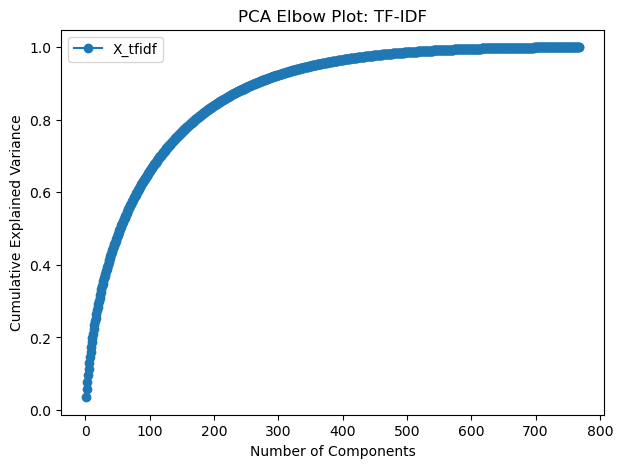

In [12]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(cumvar_tfidf)+1), cumvar_tfidf, marker='o', label="X_tfidf")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Elbow Plot: TF-IDF")
plt.legend()
plt.show()


Is this a good elbow plot? What is the conclusion that we get from this?

With text data, elbows are often weak or smooth (Why?)

### Topic Modelling

#### LDA (Latent Dirichlet Allocation)

In [13]:
# split into paragraphs
doc_clean = []
for doc in preprocessed_opinion:
    # split by paragraph
    for paragraph in doc.split("\n\n"):
        doc_clean.append(doc.split())
print(doc_clean[:2])

[['justice', 'ginsburg', 'delivered', 'opinion', 'court', 'motion', 'federal', 'prisoner', 'postconviction', 'relief', '#', 'usc', '§', '#', 'subject', 'oneyear', 'time', 'limitation', 'generally', 'runs', 'date', 'judgment', 'conviction', 'becomes', 'final', '§', '#', 'p', '#', 'case', 'concerns', 'starting', 'date', 'oneyear', 'limitation', 'presents', 'narrow', 'recurring', 'question', 'courts', 'appeals', 'divided', 'defendant', 'federal', 'prosecution', 'takes', 'unsuccessful', 'direct', 'appeal', 'judgment', 'conviction', 'next', 'petition', 'writ', 'certiorari', 'court', 'judgment', 'become', 'final', 'postconviction', 'relief', 'purposes', '#', 'appellate', 'court', 'issues', 'mandate', 'affirming', 'conviction', 'instead', '#', 'date', 'ordinarily', '#', 'days', 'later', 'time', 'filing', 'petition', 'certiorari', 'expires', 'accord', 'courts', 'consistent', 'understanding', 'finality', 'context', 'collateral', 'review', 'weight', 'lower', 'court', 'authority', 'reject', 'issu

In [14]:
# randomize document order
from random import shuffle
shuffle(doc_clean)

# creating the term dictionary
from gensim import corpora # New
dictionary = corpora.Dictionary(doc_clean)
# filter extremes, drop all words appearing in less than 10 paragraphs and all words appearing in at least every third paragraph
dictionary.filter_extremes(no_below=10, no_above=0.33, keep_n=1000)
print(len(dictionary))

1000


In [15]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow",
    category=DeprecationWarning
)

# creating the document-term matrix
doc_term_matrix = [dictionary.doc2bow(doc) for doc in doc_clean]

# train LDA with 10 topics and print
from gensim.models.ldamodel import LdaModel
lda = LdaModel(doc_term_matrix, num_topics=4,
               id2word = dictionary, passes=3)
lda.show_topics(formatted=True)

[(0,
  '0.014*"habeas" + 0.011*"death" + 0.010*"damages" + 0.007*"fees" + 0.006*"award" + 0.006*"penalty" + 0.006*"attorneys" + 0.005*"attorney" + 0.005*"california" + 0.005*"commission"'),
 (1,
  '0.013*"tax" + 0.009*"regulations" + 0.008*"regulation" + 0.007*"liability" + 0.006*"board" + 0.006*"employees" + 0.006*"contract" + 0.005*"city" + 0.005*"discrimination" + 0.005*"plaintiffs"'),
 (2,
  '0.009*"police" + 0.006*"commerce" + 0.006*"statements" + 0.006*"article" + 0.005*"limitations" + 0.005*"work" + 0.005*"testimony" + 0.005*"foreign" + 0.004*"officers" + 0.004*"house"'),
 (3,
  '0.012*"plan" + 0.011*"sentencing" + 0.011*"offense" + 0.010*"crime" + 0.008*"conviction" + 0.007*"school" + 0.006*"prison" + 0.006*"officers" + 0.006*"drug" + 0.005*"death"')]

In [16]:

import pyLDAvis.gensim
pyLDAvis.enable_notebook()
pyLDAvis.gensim.prepare(lda, doc_term_matrix, dictionary)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.047150  0.003960       1        1  37.580627
2      0.004758 -0.022718       2        1  23.112685
3     -0.037100 -0.008932       3        1  20.838955
0     -0.014807  0.027690       4        1  18.467733, topic_info=           Term         Freq        Total Category  logprob  loglift
184  sentencing  1191.000000  1191.000000  Default  30.0000  30.0000
100      habeas  1713.000000  1713.000000  Default  29.0000  29.0000
60        death  1405.000000  1405.000000  Default  28.0000  28.0000
135     offense  1230.000000  1230.000000  Default  27.0000  27.0000
533         tax  2235.000000  2235.000000  Default  26.0000  26.0000
..          ...          ...          ...      ...      ...      ...
942       funds   233.677623   991.617603   Topic4  -5.7371   0.2438
245    benefits   239.447464  1149.284716   Topic4  -5.7127   0.1206
716   political   244.836931  1271.837731   Topic4  -5.6904   0.0415
714   plaintiff   231.128469  1135.869268   Topic4  -5.7480   0.0970
56   conviction   225.489745  1164.538451   Topic4  -5.7727   0.0473

[216 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
543       1  0.507338  activity
543       2  0.342705  activity
543       3  0.089596  activity
543       4  0.060477  activity
8         1  0.078989  admitted
...     ...       ...       ...
233       4  0.326468      writ
542       1  0.384209      york
542       2  0.358161      york
542       3  0.128938      york
542       4  0.128938      york

[624 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 4, 1])

In [17]:
from gensim.models.coherencemodel import CoherenceModel

coherence_scores = []
for k in range(1, 10):
    lda = LdaModel(
        corpus=doc_term_matrix,
        num_topics=k,
        id2word=dictionary,
        passes=3,
        random_state=0
    )

    cm = CoherenceModel(
        model=lda,
        texts=doc_clean,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_scores.append(cm.get_coherence())




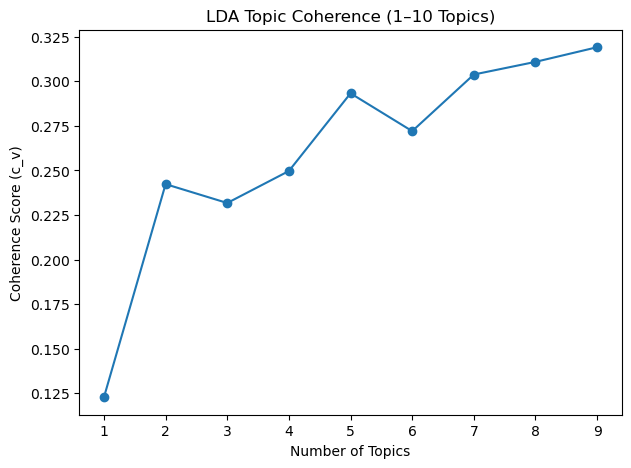

In [18]:
plt.figure(figsize=(7,5))
plt.plot(range(1,10), coherence_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA Topic Coherence (1–10 Topics)")
plt.show()

#### Author Topic Model (Structural Topic Model)

In [19]:
from gensim.models import AuthorTopicModel
from gensim.test.utils import temporary_file

df = df.reset_index()
df['id'] = df.index
author2doc = df[:100][['authorship','id']]
author2doc = author2doc.groupby('authorship').apply(lambda x: list(x['id'])).to_dict()

model = AuthorTopicModel(
        doc_term_matrix, author2doc=author2doc, id2word=dictionary, num_topics=10)

# For each author list topic distribution
author_vecs = [model.get_author_topics(author) for author in model.id2author.values()]
author_vecs[:2]

[[(0, np.float64(0.21091612807341772)),
  (1, np.float64(0.013641200080623393)),
  (2, np.float64(0.01580250102201277)),
  (5, np.float64(0.21172279715839018)),
  (7, np.float64(0.5476921872582997))],
 [(0, np.float64(0.6296074071248513)),
  (2, np.float64(0.08118611847321527)),
  (7, np.float64(0.1277310398081336)),
  (8, np.float64(0.16047037641384432))]]